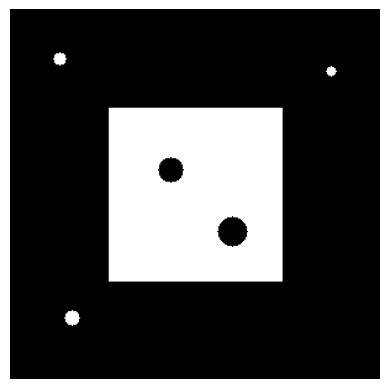

In [9]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = np.zeros((300, 300), dtype=np.uint8)

# Main white object
cv2.rectangle(img, (80, 80), (220, 220), 255, -1)

# Small white noise
cv2.circle(img, (40, 40), 5, 255, -1)
cv2.circle(img, (260, 50), 4, 255, -1)
cv2.circle(img, (50, 250), 6, 255, -1)

# Black holes inside object
cv2.circle(img, (130, 130), 10, 0, -1)
cv2.circle(img, (180, 180), 12, 0, -1)

save_path = "outputs/morphological/"
cv2.imwrite(save_path + "binary.png", img)

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()


[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


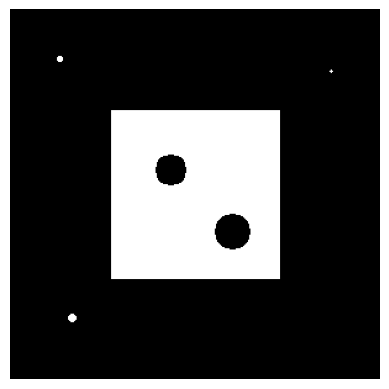

In [10]:
# Erosion
# white object becomes smaller
# small white noise may disappear
# black holes become larger
kernel = np.ones((5, 5), np.uint8)
print(kernel)
eroded = cv2.erode(img, kernel, iterations=1)
cv2.imwrite(save_path + "eroded.png", eroded)
plt.imshow(eroded, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

# More iterations, more erosion
for i in range(1, 4):
    eroded = cv2.erode(img, kernel, iterations=i)
    cv2.imwrite(save_path + f"eroded_{i}.png", eroded)

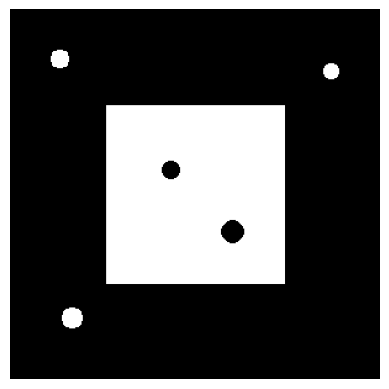

In [20]:
# Dilatation
# white object becomes larger
# small white noise becomes larger
# black holes become smaller
# nearby white regions may connect

kernel = np.ones((5, 5), np.uint8)
dilated = cv2.dilate(img, kernel, iterations=1)
cv2.imwrite(save_path + "dilated.png", dilated)
plt.imshow(dilated, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

# More iterations, more erosion
for i in range(1, 4):
    dilated = cv2.dilate(img, kernel, iterations=i)
    cv2.imwrite(save_path + f"dilated_{i}.png", dilated)

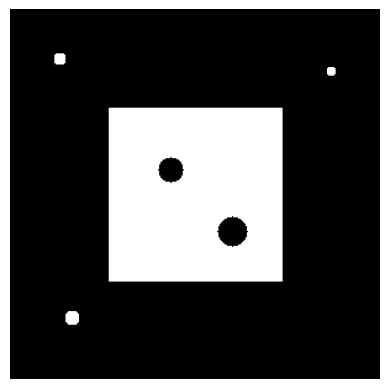

True

In [16]:
# Opening
# erosion → dilation

# Observe:
# small white noise disappears
# main object mostly remains
# black holes are not fixed

# Practical use:
# clean a noisy threshold mask
# clean an HSV color mask
# remove isolated false detections
kernel_3 = np.ones((3, 3), np.uint8)
kernel_5 = np.ones((5, 5), np.uint8)
kernel_9 = np.ones((9, 9), np.uint8)

open_3 = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_3)
open_5 = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_5)
open_9 = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_9)
opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
plt.imshow(opened, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()
cv2.imwrite(save_path + "opened_3.png", opened)
cv2.imwrite(save_path + "opened_3.png", open_3)
cv2.imwrite(save_path + "opened_5.png", open_5)
cv2.imwrite(save_path + "opened_9.png", open_9)


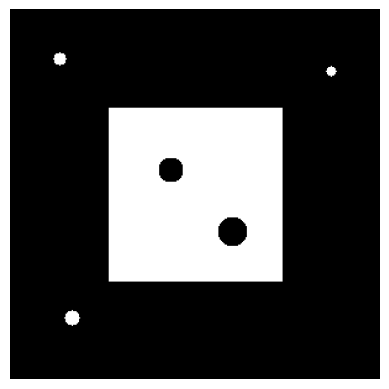

True

In [18]:
# Closing
# dilation → erosion
close_3 = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_3)
close_5 = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_5)
close_9 = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_9)
plt.imshow(close_3, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

cv2.imwrite(save_path + "close_3.png", close_3)
cv2.imwrite(save_path + "close_5.png", close_5)
cv2.imwrite(save_path + "close_9.png", close_9)

In [19]:
# different kernel shapes
rect_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
ellipse_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
cross_kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (7, 7))

opened_rect = cv2.morphologyEx(img, cv2.MORPH_OPEN, rect_kernel)
opened_ellipse = cv2.morphologyEx(img, cv2.MORPH_OPEN, ellipse_kernel)
opened_cross = cv2.morphologyEx(img, cv2.MORPH_OPEN, cross_kernel)

cv2.imwrite(save_path + "open_rect.png", opened_rect)
cv2.imwrite(save_path + "open_ellipse.png", opened_ellipse)
cv2.imwrite(save_path + "open_cross.png", opened_cross)

True